Ball bleibt in der Mauer hängen.
Kein Tor.


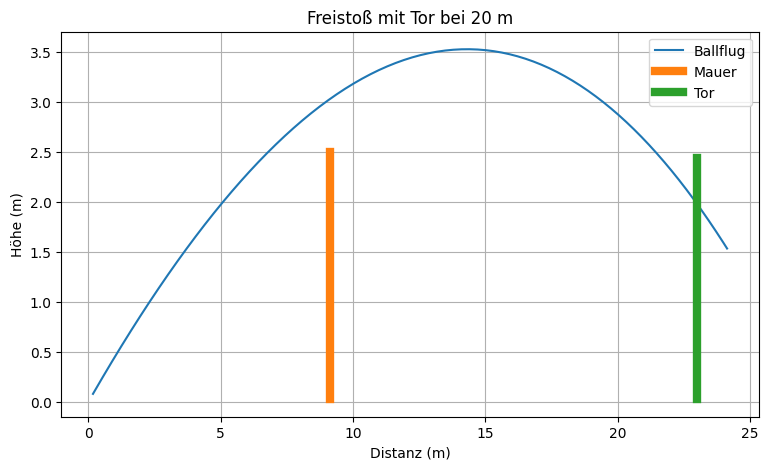

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Konstanten
# -----------------------------
g = 9.81    # Erdbeschleunigung in m/s^2
dichteLuft = 1.2   # Dichte der Luft in kg/m^3
lwBeiwert = 0.2   # Luftwiderstandsbeiwert für einen runden Ball
Cl = 0.2    # Auftriebsbeiwert (nicht perfekt glatt)
r = 0.11    # Radius des Balls in m
A = np.pi * r**2    # Querschnittsfläche des Balls
m = 0.43    # Masse des Balls in kg

# -----------------------------
# Spielfeld
# -----------------------------
mauer_x = 9.15
mauer_h = 2.50

FeldEnde = 23.0
tor_h = 2.44

# ----------------------------------------------------------------------
# Freistoß werte variabel zum eintellen
# ---------------------------------------------------------------------
v0 = 20
winkel = 25
spin = 5   # Topspin
dt = 0.01

winkel_rad = np.radians(winkel)

v = np.array([v0*np.cos(winkel_rad), v0*np.sin(winkel_rad)])    # Anfangsgeschwindigkeit in x- und y-Richtung
pos = np.array([0.0, 0.0])  # Startposition des Balls2

positionen = [] # Liste für die Positionen des Balls
ueber_mauer = False
im_tor = False

# -----------------------------
# Simulation
# -----------------------------
while pos[1] >= 0 and pos[0] <= FeldEnde + 1:      # Solange der Ball den Boden nicht erreicht hat und nicht zu weit über das Tor hinausfliegt
    gesamtgeschwindigkeit = np.linalg.norm(v)   # Betrag der Geschwindigkeit; np.linalg.norm(v) = Länge des Geschwindigkeitsvektors v
    
    F_drag = -0.5 * dichteLuft * lwBeiwert * A * gesamtgeschwindigkeit * v    # Luftwiderstand
    
    F_magnus = 0.5 * dichteLuft * Cl * A * np.array([ -spin * v[1],spin * v[0]]) # Magnus-Kraft, basierend auf der Rotation des Balls
    
    F_gravity = np.array([0, -m*g])             # Schwerkraft
    a = (F_drag + F_magnus + F_gravity) / m     # Gesamtkraft pro Masse = Beschleunigung
    
    v += a * dt                     # Geschwindigkeit aktualisieren
    pos += v * dt                   # Position aktualisieren
    positionen.append(pos.copy())   # Positionen für Plot speichern
    
    # Prüfen: über Mauer?
    if abs(pos[0] - mauer_x) < 0.05 and pos[1] > mauer_h:
        ueber_mauer = True
    
    # Prüfen: im Tor?
    if abs(pos[0] - FeldEnde) < 0.05 and 0 < pos[1] < tor_h:
        im_tor = True

positionen = np.array(positionen)

# -----------------------------
# Ausgabe
# -----------------------------
if ueber_mauer:
    print("Ball kommt über die Mauer.")
else:
    print("Ball bleibt in der Mauer hängen.")

if im_tor and ueber_mauer:
    print("TOR!!!")
else:
    print("Kein Tor.")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(positionen[:,0], positionen[:,1], label="Ballflug")

# Mauer
plt.plot([mauer_x, mauer_x], [0.03, mauer_h], linewidth=6, label="Mauer")

# Tor
plt.plot([FeldEnde, FeldEnde], [0.03, tor_h], linewidth=6, label="Tor")

plt.xlabel("Distanz (m)")
plt.ylabel("Höhe (m)")
plt.title("Freistoß mit Tor bei 20 m")
plt.legend()
plt.grid()
plt.show()

Ball kommt über die Mauer.
Kein Tor.


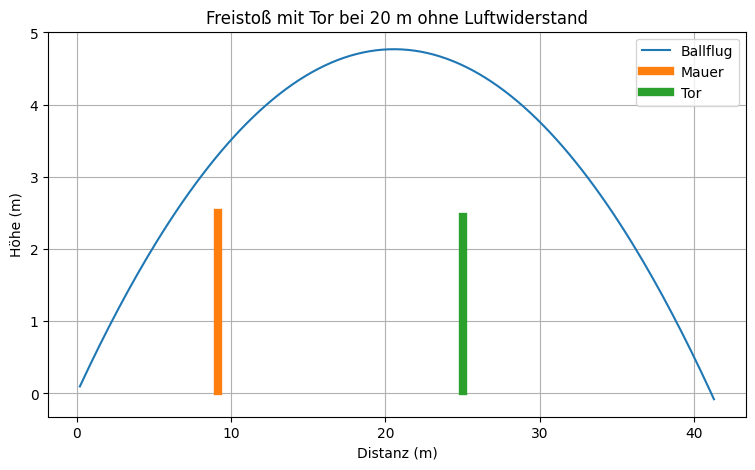

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Konstanten
# -----------------------------
g = 9.81    # Erdbeschleunigung in m/s^2
dichteLuft = 0   # Dichte der Luft in kg/m^3
lwBeiwert = 0.0   # Luftwiderstandsbeiwert für einen runden Ball
Cl = 0.2    # Magnus-Koeffizient (nicht perfekt glatt)
r = 0.11    # Radius des Balls in m
A = np.pi * r**2    # Querschnittsfläche des Balls
m = 0.43    # Masse des Balls in kg

# -----------------------------
# Spielfeld
# -----------------------------
mauer_x = 9.15
mauer_h = 2.50

FeldEnde = 25.0
tor_h = 2.44

# ----------------------------------------------------------------------
# Freistoß werte variabel zum eintellen
# ---------------------------------------------------------------------
v0 = 23
winkel = 25
spin = 10           # Backspin
dt = 0.01
dichteLuft = 0      # Dichte der Luft in kg/m^3
lwBeiwert = 0.0     # Luftwiderstandsbeiwert für einen runden Ball

winkel_rad = np.radians(winkel)

v = np.array([v0*np.cos(winkel_rad), v0*np.sin(winkel_rad)])    # Anfangsgeschwindigkeit in x- und y-Richtung
pos = np.array([0.0, 0.0])  # Startposition des Balls

positionen = [] # Liste für die Positionen des Balls
ueber_mauer = False
im_tor = False

# -----------------------------
# Simulation
# -----------------------------
while pos[1] >= 0:      # Solange der Ball den Boden nicht erreicht hat und nicht zu weit über das Tor hinausfliegt
    gesamtgeschwindigkeit = np.linalg.norm(v)   # Betrag der Geschwindigkeit; np.linalg.norm(v) = Länge des Geschwindigkeitsvektors v
    
    F_drag = -0.5 * dichteLuft * lwBeiwert * A * gesamtgeschwindigkeit * v    # Luftwiderstand
    
    F_magnus = 0.5 * dichteLuft * Cl * A * np.array([ -spin * v[1],spin * v[0]]) # Magnus-Kraft, basierend auf der Rotation des Balls
    
    F_gravity = np.array([0, -m*g])             # Schwerkraft
    a = (F_drag + F_magnus + F_gravity) / m     # Gesamtkraft pro Masse = Beschleunigung
    
    v += a * dt                     # Geschwindigkeit aktualisieren
    pos += v * dt                   # Position aktualisieren
    positionen.append(pos.copy())   # Positionen für Plot speichern
    
    # Prüfen: über Mauer?
    if abs(pos[0] - mauer_x) < 0.05 and pos[1] > mauer_h:
        ueber_mauer = True
    
    # Prüfen: im Tor?
    if abs(pos[0] - FeldEnde) < 0.05 and 0 < pos[1] < tor_h:
        im_tor = True

positionen = np.array(positionen)

# -----------------------------
# Ausgabe
# -----------------------------
if ueber_mauer:
    print("Ball kommt über die Mauer.")
else:
    print("Ball bleibt in der Mauer hängen.")

if im_tor and ueber_mauer:
    print("TOR!!!")
else:
    print("Kein Tor.")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(positionen[:,0], positionen[:,1], label="Ballflug")

# Mauer
plt.plot([mauer_x, mauer_x], [0.03, mauer_h], linewidth=6, label="Mauer")

# Tor
plt.plot([FeldEnde, FeldEnde], [0.03, tor_h], linewidth=6, label="Tor")

plt.xlabel("Distanz (m)")
plt.ylabel("Höhe (m)")
plt.title("Freistoß mit Tor bei 20 m ohne Luftwiderstand")
plt.legend()
plt.grid()
plt.show()